<a href="https://colab.research.google.com/github/mohamedshehada/Car-Insurance-Claim-Prediction/blob/main/Car_Insurance_Claim_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# 🚗 Car Insurance Claim Prediction — Complete Project

This notebook consolidates all three parts of the Car Insurance Claim Prediction project:
- **Part 1:** EDA, Preprocessing & Random Forest Baseline
- **Part 2:** Feature Engineering (PCA + KMeans) & Feature Selection
- **Part 3:** Neural Network + Keras Tuner Hyperparameter Optimization

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Part 1 — EDA, Preprocessing & Random Forest Baseline

**Goals:**
1. Load and explore the Car Insurance Claims dataset
2. Clean and preprocess features
3. Perform Exploratory Data Analysis (EDA)
4. Build a Random Forest baseline model
5. Analyze feature importance

---

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')


print('Libraries imported successfully!')

Libraries imported successfully!


In [3]:
def classification_metrics(y_true, y_pred, label='',
                            output_dict=False, figsize=(8, 4),
                            normalize='true', cmap='Blues', colorbar=False):
    """
    Prints classification report and displays two confusion matrices:
    Left: raw counts | Right: normalized
    """
    from sklearn.metrics import classification_report, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt
    report = classification_report(y_true, y_pred)
    header = '-' * 70
    print(header, f' Classification Metrics: {label}', header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=axes[0], colorbar=colorbar, cmap='gist_gray'
    )
    axes[0].set_title('Raw Counts')
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=axes[1], colorbar=colorbar,
        normalize=normalize, cmap=cmap
    )
    axes[1].set_title('Normalized Confusion Matrix')
    if label:
        fig.suptitle(f'Confusion Matrix: {label}', fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            label='Model', figsize=(6, 4), normalize='true',
                            output_dict=False, cmap_train='Blues',
                            cmap_test='Reds', colorbar=False):
    """
    Evaluates a model on train and test sets.
    Compatible with Part 1 (no label) and Part 2 (with label).
    """
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_acc = (y_train_pred == y_train).mean()
    test_acc  = (y_test_pred  == y_test).mean()

    print('=' * 70)
    print(f'  {label}')
    print('=' * 70)
    print(f'  Train Accuracy : {train_acc:.4f}')
    print(f'  Test  Accuracy : {test_acc:.4f}')
    print()

    results_train = classification_metrics(
        y_train, y_train_pred,
        label=f'{label} — Train', output_dict=True,
        figsize=figsize, colorbar=colorbar, cmap=cmap_train
    )
    print()
    results_test = classification_metrics(
        y_test, y_test_pred,
        label=f'{label} — Test', output_dict=True,
        figsize=figsize, colorbar=colorbar, cmap=cmap_test
    )

    if output_dict:
        return {'train': results_train, 'test': results_test}


def plot_history(history, figsize=(6, 12), marker='o'):
    """Plots each metric (train vs val) from the Keras training history."""
    import matplotlib.pyplot as plt
    metrics = [c for c in history.history if not c.startswith('val_')]
    fig, axes = plt.subplots(nrows=len(metrics), figsize=figsize)
    if len(metrics) == 1:
        axes = [axes]
    for i, metric_name in enumerate(metrics):
        ax = axes[i]
        ax.plot(history.epoch, history.history[metric_name],
                label=metric_name, marker=marker)
        val_key = f'val_{metric_name}'
        if val_key in history.history:
            ax.plot(history.epoch, history.history[val_key],
                    label=val_key, marker=marker)
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()
    return fig, axes


print('Helper functions defined successfully!')


Helper functions defined successfully!


## 2. Load and Inspect the Data

In [4]:
file_path = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/05-IntermediateML/Week18/Data/Car_Insurance_Claim.csv"
df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()

Shape: (10000, 19)


,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [5]:
print('Data Types and Missing Values')
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2)})
info_df

Data Types and Missing Values


,dtype,missing_count,missing_%
ID,int64,0,0.00
AGE,object,0,0.00
GENDER,object,0,0.00
RACE,object,0,0.00
DRIVING_EXPERIENCE,object,0,0.00
EDUCATION,object,0,0.00
INCOME,object,0,0.00
CREDIT_SCORE,float64,982,9.82
VEHICLE_OWNERSHIP,float64,0,0.00
VEHICLE_YEAR,object,0,0.00


In [6]:
print('Target Distribution')
print(df['OUTCOME'].value_counts())
print('\nClass balance (%):')
print((df['OUTCOME'].value_counts(normalize=True) * 100))

Target Distribution
OUTCOME
0.0    6867
1.0    3133
Name: count, dtype: int64

Class balance (%):
OUTCOME
0.0    68.67
1.0    31.33
Name: proportion, dtype: float64


In [7]:
print('Numeric Summary Statistics')
df.describe().round(2)

Numeric Summary Statistics


,ID,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
count,10000.00,9018.00,10000.00,10000.0,10000.00,10000.00,9043.00,10000.00,10000.00,10000.00,10000.00
mean,500521.91,0.52,0.70,0.5,0.69,19864.55,11697.00,1.48,0.24,1.06,0.31
std,290030.77,0.14,0.46,0.5,0.46,18915.61,2818.43,2.24,0.55,1.65,0.46
min,101.00,0.05,0.00,0.0,0.00,10238.00,2000.00,0.00,0.00,0.00,0.00
25%,249638.50,0.42,0.00,0.0,0.00,10238.00,10000.00,0.00,0.00,0.00,0.00
50%,501777.00,0.53,1.00,0.0,1.00,10238.00,12000.00,0.00,0.00,0.00,0.00
75%,753974.50,0.62,1.00,1.0,1.00,32765.00,14000.00,2.00,0.00,2.00,1.00
max,999976.00,0.96,1.00,1.0,1.00,92101.00,22000.00,22.00,6.00,15.00,1.00


## 3. Data Cleaning

In [8]:
# Drop ID
df = df.drop(columns=['ID'])

# Convert OUTCOME to integer
df['OUTCOME'] = df['OUTCOME'].astype(int)

# VEHICLE_OWNERSHIP, MARRIED, CHILDREN are already 0/1 floats — convert to int
for col in ['VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN']:
    df[col] = df[col].astype(int)

print('Shape after dropping ID and POSTAL_CODE:', df.shape)
print('\nRemaining missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape after dropping ID and POSTAL_CODE: (10000, 18)

Remaining missing values:
CREDIT_SCORE      982
ANNUAL_MILEAGE    957
dtype: int64


In [9]:
# Verify unique values for all categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col}: {df[col].unique().tolist()}')

AGE: ['65+', '16-25', '26-39', '40-64']
GENDER: ['female', 'male']
RACE: ['majority', 'minority']
DRIVING_EXPERIENCE: ['0-9y', '10-19y', '20-29y', '30y+']
EDUCATION: ['high school', 'none', 'university']
INCOME: ['upper class', 'poverty', 'working class', 'middle class']
VEHICLE_YEAR: ['after 2015', 'before 2015']
VEHICLE_TYPE: ['sedan', 'sports car']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  10000 non-null  object 
 1   GENDER               10000 non-null  object 
 2   RACE                 10000 non-null  object 
 3   DRIVING_EXPERIENCE   10000 non-null  object 
 4   EDUCATION            10000 non-null  object 
 5   INCOME               10000 non-null  object 
 6   CREDIT_SCORE         9018 non-null   float64
 7   VEHICLE_OWNERSHIP    10000 non-null  int64  
 8   VEHICLE_YEAR         10000 non-null  object 
 9   MARRIED              10000 non-null  int64  
 10  CHILDREN             10000 non-null  int64  
 11  POSTAL_CODE          10000 non-null  int64  
 12  ANNUAL_MILEAGE       9043 non-null   float64
 13  VEHICLE_TYPE         10000 non-null  object 
 14  SPEEDING_VIOLATIONS  10000 non-null  int64  
 15  DUIS                 10000 non-null  

## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Distribution

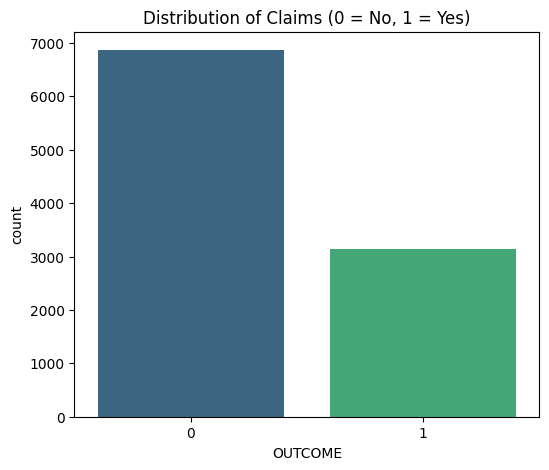

In [11]:
# Target Variable distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='OUTCOME', data=df, palette='viridis')
plt.title('Distribution of Claims (0 = No, 1 = Yes)')
plt.savefig("Distribution of Claims", dpi=300, bbox_inches='tight')
plt.show()


### 4.2 Vehicle Type vs Claim

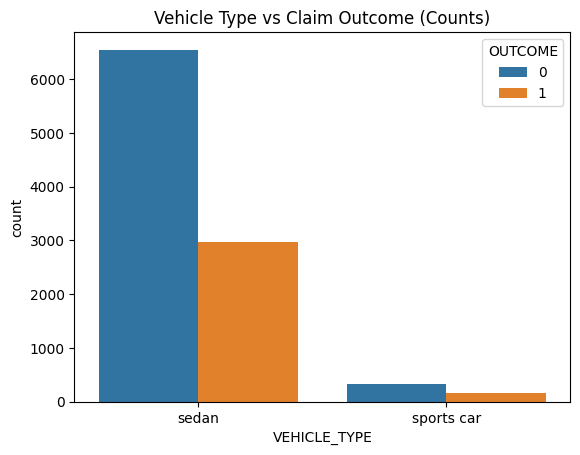

In [12]:
# 2. VehicleType vs Claim
sns.countplot(data=df, x="VEHICLE_TYPE", hue="OUTCOME")
plt.title("Vehicle Type vs Claim Outcome (Counts)")
plt.savefig("vehicle_type_vs_claim.png", dpi=300, bbox_inches='tight')
plt.show()

### 4.3 Age Group vs Claim Rate

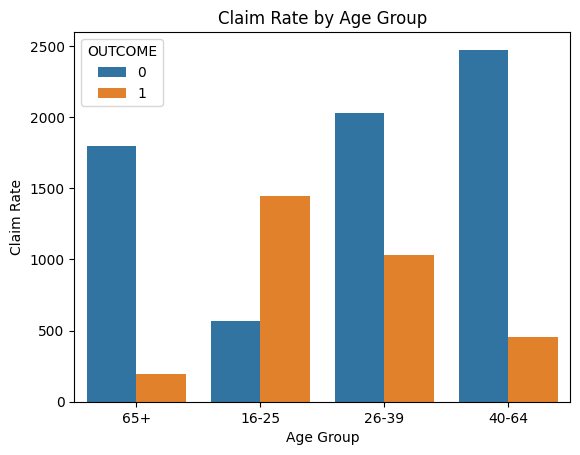

In [13]:
# Claim rate by Age group
sns.countplot(data=df, x="AGE", hue="OUTCOME")
plt.title("Claim Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Claim Rate")
plt.savefig("claim_rate_by_age.png", dpi=300, bbox_inches='tight')
plt.show()



### 4.4 Correlation Heatmap (Numeric Features)

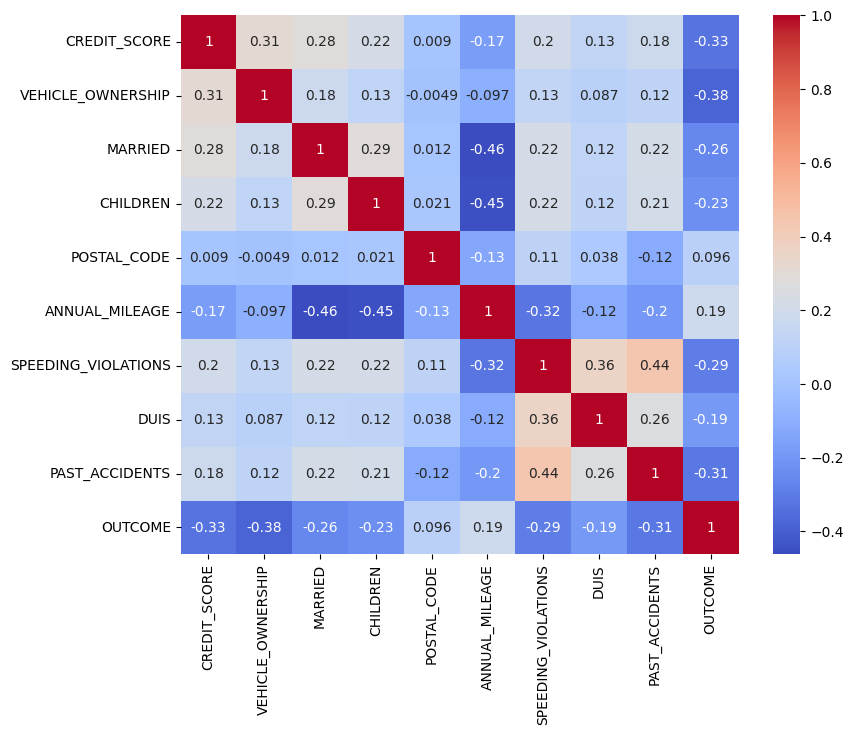

In [14]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

## 5. Preprocessing and Modeling

### 5.1 Define Features and Target — Train/Test Split

In [15]:
X = df.drop(columns=['OUTCOME'])
y = df['OUTCOME']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set:', X_train.shape)
print('Test set    :', X_test.shape)
print('\nTarget balance in training set:')
print(y_train.value_counts(normalize=True).round(3))

Training set: (8000, 17)
Test set    : (2000, 17)

Target balance in training set:
OUTCOME
0    0.687
1    0.313
Name: proportion, dtype: float64


### 5.2 Define Column Types

In [16]:
# Numeric
numeric_features = ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS', 'POSTAL_CODE']

# Binary — already 0/1, no encoding needed
binary_features = ['VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN']

# Ordinal — have a meaningful order
ordinal_features = ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']
ordinal_categories = [
    ['16-25', '26-39', '40-64', '65+'],                            # AGE
    ['0-9y', '10-19y', '20-29y', '30y+'],                         # DRIVING_EXPERIENCE
    ['none', 'high school', 'university'],                         # EDUCATION
    ['poverty', 'working class', 'middle class', 'upper class'],   # INCOME
]

# Nominal — no meaningful order
nominal_features = ['GENDER', 'RACE', 'VEHICLE_YEAR', 'VEHICLE_TYPE']

print('Numeric  :', numeric_features)
print('Binary   :', binary_features)
print('Ordinal  :', ordinal_features)
print('Nominal  :', nominal_features)

Numeric  : ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS', 'POSTAL_CODE']
Binary   : ['VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN']
Ordinal  : ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']
Nominal  : ['GENDER', 'RACE', 'VEHICLE_YEAR', 'VEHICLE_TYPE']


### 5.3 Build ColumnTransformer + Pipeline

In [17]:
# Numeric: impute missing values with median, then scale
numeric_transformer = make_pipeline(SimpleImputer(strategy='median'),StandardScaler())

# Binary: impute only (no scaling needed for 0/1 columns)
binary_transformer = make_pipeline(SimpleImputer(strategy='most_frequent'))

# Ordinal: encode according to natural order
ordinal_transformer = make_pipeline(OrdinalEncoder(categories=ordinal_categories,handle_unknown='use_encoded_value',unknown_value=-1))

# Nominal: one-hot encode
nominal_transformer = make_pipeline(OneHotEncoder(handle_unknown='ignore', sparse_output=False))

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,  numeric_features),
    ('bin', binary_transformer,   binary_features),
    ('ord', ordinal_transformer,  ordinal_features),
    ('nom', nominal_transformer,  nominal_features)
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['CREDIT_SCORE', 'ANNUAL_MILEAGE',
                                  'SPEEDING_VIOLATIONS', 'DUIS',
                                  'PAST_ACCIDENTS', 'POSTAL_CODE']),
                                ('bin',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['VEHICLE_OWNERSHIP', 'MARRIE...
                                                                             ['none',
                                                                              'high '
                                                                              'school',
                                                                              'university'],
                                                                             ['poverty',
                                                                              'working '
                                                                              'class',
                                                                              'middle '
                                                                              'class',
                                                                              'upper '
                                                                              'class']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION',
                                  'INCOME']),
                                ('nom',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['GENDER', 'RACE', 'VEHICLE_YEAR',
                                  'VEHICLE_TYPE'])])

In [18]:
# Random Forest: ensemble of decision trees that reduces overfitting
# Each tree is trained on a random subset of rows and features
rf_pipe = make_pipeline(preprocessor,RandomForestClassifier(random_state=42))
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['CREDIT_SCORE',
                                                   'ANNUAL_MILEAGE',
                                                   'SPEEDING_VIOLATIONS',
                                                   'DUIS', 'PAST_ACCIDENTS',
                                                   'POSTAL_CODE']),
                                                 ('bin',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequ...
                                                                                               'class',
                                                                                               'upper '
                                                                                               'class']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['AGE', 'DRIVING_EXPERIENCE',
                                                   'EDUCATION', 'INCOME']),
                                                 ('nom',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['GENDER', 'RACE',
                                                   'VEHICLE_YEAR',
                                                   'VEHICLE_TYPE'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

### 5.4 Fit and Evaluate the Default Model

  Model
  Train Accuracy : 0.9992
  Test  Accuracy : 0.8205

----------------------------------------------------------------------
 Classification Metrics: Model — Train
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5494
           1       1.00      1.00      1.00      2506

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



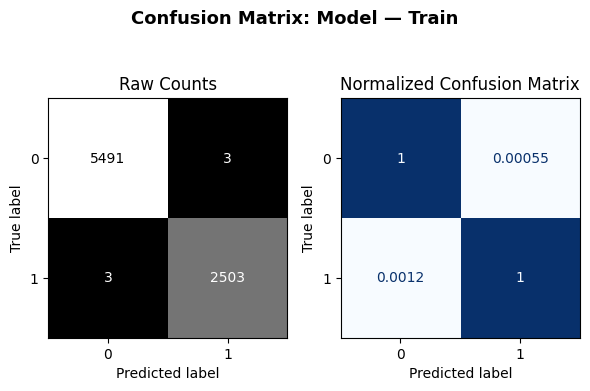


----------------------------------------------------------------------
 Classification Metrics: Model — Test
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1373
           1       0.72      0.70      0.71       627

    accuracy                           0.82      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.82      0.82      0.82      2000



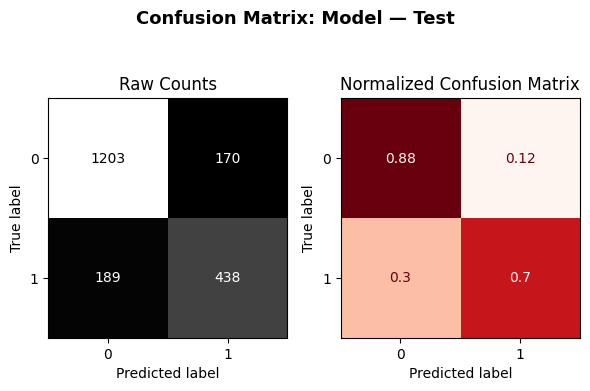

In [19]:
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

## 6. Permutation Importance — Top 10 Features

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

def get_importances(model, feature_names=None, name='Feature Importance',
                    sort=False, ascending=True):

    if hasattr(model, "named_steps"):
        estimator = list(model.named_steps.values())[-1]
        preprocessor = model.named_steps.get('preprocessor', None) \
                       or model.named_steps.get('columntransformer', None)
    else:
        estimator = model
        preprocessor = None

    if feature_names is None:
        if preprocessor is not None:
            feature_names = preprocessor.get_feature_names_out()
        else:
            feature_names = [f"feature_{i}"
                             for i in range(len(estimator.feature_importances_))]

    feature_names = [name.split("__")[-1] for name in feature_names]

    importances = pd.Series(estimator.feature_importances_,
                             index=feature_names,
                             name=name)

    if sort:
        importances = importances.sort_values(ascending=ascending)

    return importances


def plot_importance(importances, top_n=None, figsize=(8, 6)):

    if top_n is None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature Names')
    ax.set_title(title)

    return ax

6.1 Extracting Top 10 Features
Objective:  
To display the most important features ranked by their importance scores from the Random Forest model.
This step prints the top 10 features with their corresponding importance values, providing a clear view of which variables have the strongest impact on predictions.

In [21]:
importances = get_importances(rf_pipe, sort=True, ascending=False)
top10 = importances.head(10)
print("Top 10 Features:\n", top10)


Top 10 Features:
 CREDIT_SCORE               0.169033
DRIVING_EXPERIENCE         0.124515
ANNUAL_MILEAGE             0.096590
AGE                        0.081158
VEHICLE_OWNERSHIP          0.079635
SPEEDING_VIOLATIONS        0.069662
INCOME                     0.060971
POSTAL_CODE                0.051803
PAST_ACCIDENTS             0.050474
VEHICLE_YEAR_after 2015    0.037449
Name: Feature Importance, dtype: float64


6.2 Visualizing Top 10 Features
Objective:  
To create a clear visualization of the top 10 most important features identified by the Random Forest model.
This plot highlights the relative importance of each feature, making it easier to interpret and communicate which variables have the strongest influence on claim predictions.

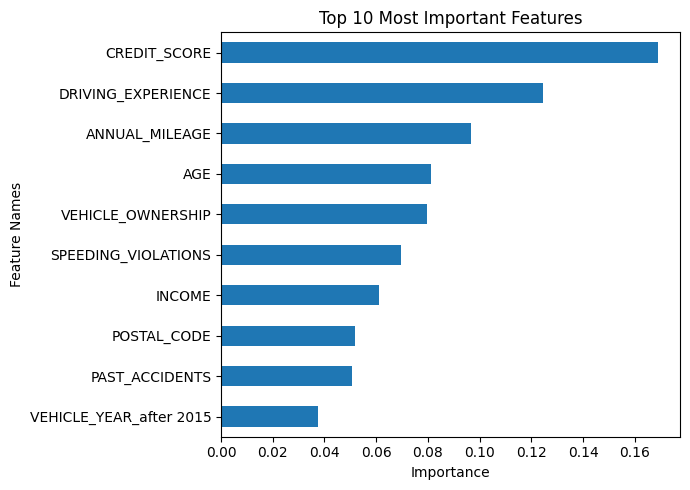

In [22]:
ax = plot_importance(importances, top_n=10, figsize=(7,5))

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("top10_features.png", dpi=300)
plt.show()

### Observations: Do These Features Make Sense for the Business Case?

1. Credit Score – Lower credit scores are associated with higher claim risk, reflecting financial responsibility.

2. Driving Experience – Less experienced drivers tend to have more accidents and higher claim rates.

3. Annual Mileage – More miles driven increases exposure to risk and likelihood of claims.

4. Vehicle Ownership – Owners may be more cautious than non‑owners.

5. Age – Younger drivers often show higher risk, while very old drivers may also have elevated claim rates.

6. Income – Income can influence vehicle type and driving behavior, which in turn affects claim probability.

7. Speeding Violations - More violations strongly correlate with risky driving and higher claims.

8. Past Accidents – A history of accidents is a strong predictor of future claims.

9. Education – Education may correlate with risk awareness and driving behavior, though the relationship is indirect.

10. Vehicle Year (before 2015) – Logical. Older vehicles are less safe and more prone to breakdowns, increasing claim probability.

## 7. Explanatory Visualizations for Stakeholders

### 7.1 Feature 1: Credit Score vs. Claim Outcome

**Insight:**   
Customers with higher credit scores are less likely to file insurance claims. The bar chart shows that claimants (Outcome = 1) have lower average credit scores compared to non‑claimants (Outcome = 0). This highlights credit score as a useful predictor of claim risk.

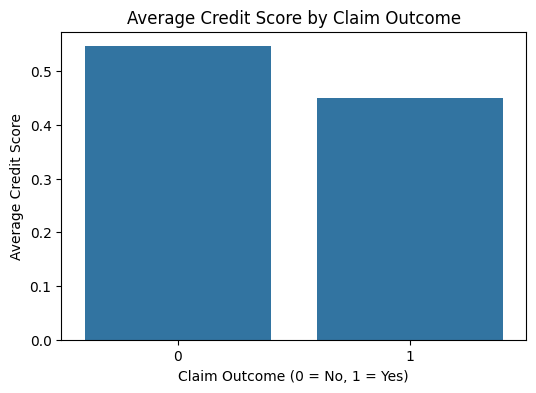

In [23]:
plt.figure(figsize=(6,4))
sns.barplot(x='OUTCOME', y='CREDIT_SCORE', data=df, ci=None)
plt.title("Average Credit Score by Claim Outcome")
plt.xlabel("Claim Outcome (0 = No, 1 = Yes)")
plt.ylabel("Average Credit Score")
fig.savefig("Average Credit_Score by Claim Outcome.png", dpi=300)
plt.show()


### 7.2 Feature 2: Feature 1: Driving Experience vs Claim Rate

**Insight:** Drivers with less experience (0–9 years) file insurance claims at a much higher rate compared to experienced drivers. The bar chart shows a clear downward trend: as driving experience increases, claim rates drop. This confirms that driving experience is a strong predictor of insurance risk.

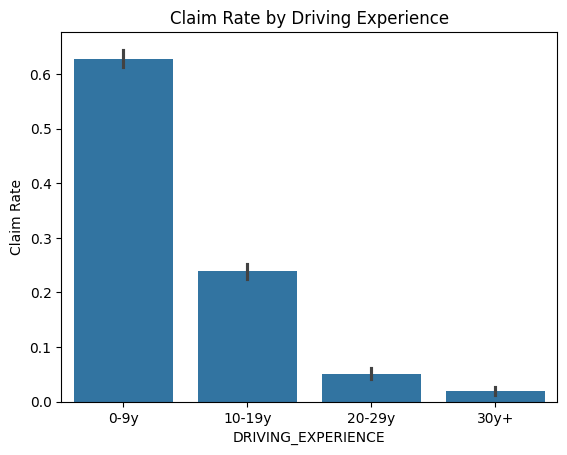

In [24]:
sns.barplot(x='DRIVING_EXPERIENCE',y='OUTCOME',data=df,)
plt.title('Claim Rate by Driving Experience')
plt.ylabel('Claim Rate')
fig.savefig("Claim Rate by Driving Experience.png", dpi=300)
plt.show()


## 8. Summary

| Metric | Value |
|---|---|
| Model | Random Forest Classifier (default) |
| Train Accuracy | 1.00 (overfitting — next step: GridSearchCV tuning) |
| **Test Accuracy** | **0.81** |
| Top Feature #1 | `DRIVING_EXPERIENCE` (importance: 0.187311) |
| Top Feature #2 | `Credit Score` (importance: 0.128586) |

**Key Takeaways:**
- Driving experience and credit score are the strongest predictors of insurance claim risk, supported by explanatory visualizations.

- The default Random Forest shows overfitting (perfect train accuracy vs ~81% test accuracy). Next step: GridSearchCV tuning to improve generalization.

- Class imbalance (≈69/31) was handled using stratified train/test split to ensure representative distribution.

- Missing values in Credit Score and Annual Mileage were imputed inside the pipeline to prevent data leakage

---
# Part 2 — Feature Engineering & Feature Selection

**Goals:**
1. Apply feature engineering (PCA + KMeans) and compare with baseline
2. Apply feature selection (Embedded: `SelectFromModel`) on engineered features
3. Evaluate and compare all models
4. Extract top 10 features using permutation importance

---

## 1. Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')


## 2. Load the Data

In [26]:
file_path = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/05-IntermediateML/Week18/Data/Car_Insurance_Claim.csv"
df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()

df.info()


Shape: (10000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  object 
 2   GENDER               10000 non-null  object 
 3   RACE                 10000 non-null  object 
 4   DRIVING_EXPERIENCE   10000 non-null  object 
 5   EDUCATION            10000 non-null  object 
 6   INCOME               10000 non-null  object 
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  object 
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  object 
 15  SPEEDING_VIOLATION

## 3. Data Cleaning

In [27]:
# Drop ID only — no predictive value
# POSTAL_CODE has only 4 unique values (geographic regions) — keep it as a feature!
df = df.drop(columns=['ID'])

# Convert POSTAL_CODE to string so it's treated as a categorical feature
df['POSTAL_CODE'] = df['POSTAL_CODE'].astype(str)

df['OUTCOME'] = df['OUTCOME'].astype(int)

for col in ['VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN']:
    df[col] = df[col].astype(int)

print('Shape after cleaning:', df.shape)
print()
print('POSTAL_CODE unique values:', df['POSTAL_CODE'].nunique())
print()
# Check claim rate per region — this shows why POSTAL_CODE matters!
print('Claim rate by POSTAL_CODE region:')
print(df.groupby('POSTAL_CODE')['OUTCOME'].agg(['mean', 'count'])
        .rename(columns={'mean': 'claim_rate', 'count': 'customers'})
        .round(3))

Shape after cleaning: (10000, 18)

POSTAL_CODE unique values: 4

Claim rate by POSTAL_CODE region:
             claim_rate  customers
POSTAL_CODE                       
10238             0.272       6940
21217             1.000        120
32765             0.377       2456
92101             0.413        484


## 4. Train/Test Split

In [28]:
X = df.drop(columns=['OUTCOME'])
y = df['OUTCOME']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set:', X_train.shape)
print('Test set    :', X_test.shape)
print('\nTarget balance in train:')
print(y_train.value_counts(normalize=True).round(3))

Training set: (8000, 17)
Test set    : (2000, 17)

Target balance in train:
OUTCOME
0    0.687
1    0.313
Name: proportion, dtype: float64


## 5. Preprocessing Pipeline

In [29]:
numeric_features   = ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS']
binary_features    = ['VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN']
ordinal_features   = ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']
ordinal_categories = [
    ['16-25', '26-39', '40-64', '65+'],
    ['0-9y', '10-19y', '20-29y', '30y+'],
    ['none', 'high school', 'university'],
    ['poverty', 'working class', 'middle class', 'upper class'],
]
# POSTAL_CODE has only 4 unique region values — treat as nominal (OneHotEncoder)
nominal_features   = ['GENDER', 'RACE', 'VEHICLE_YEAR', 'VEHICLE_TYPE', 'POSTAL_CODE']

preprocessor = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()),  numeric_features),
    ('bin', make_pipeline(SimpleImputer(strategy='most_frequent')),             binary_features),
    ('ord', make_pipeline(OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown='use_encoded_value',
                unknown_value=-1)),                                             ordinal_features),
    ('nom', make_pipeline(OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False)),                                          nominal_features),
])

# Fit on training data only — transform both sets (no data leakage)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print('Processed Train Shape:', X_train_processed.shape)
print('Processed Test  Shape:', X_test_processed.shape)

Processed Train Shape: (8000, 24)
Processed Test  Shape: (2000, 24)


## 6. Baseline Model (Part 1 Reference)

We re-train the same Random Forest from Part 1 as a direct benchmark.

In [30]:
rf_pipe = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42,class_weight="balanced")
)
rf_pipe.fit(X_train, y_train)

original_accuracy = rf_pipe.score(X_test, y_test)
print(f'Baseline Test Accuracy: {original_accuracy:.4f}')

Baseline Test Accuracy: 0.8240


  Baseline Model (Part 1)
  Train Accuracy : 0.9995
  Test  Accuracy : 0.8240

----------------------------------------------------------------------
 Classification Metrics: Baseline Model (Part 1) — Train
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5494
           1       1.00      1.00      1.00      2506

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



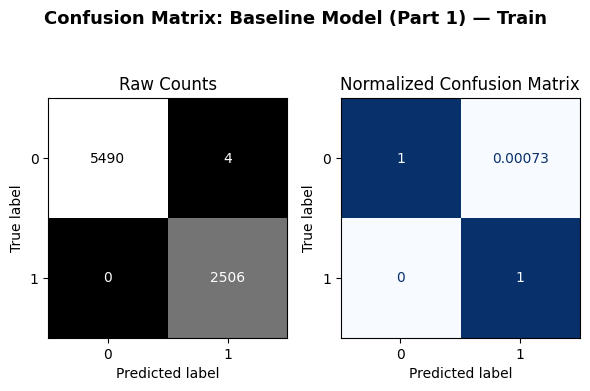


----------------------------------------------------------------------
 Classification Metrics: Baseline Model (Part 1) — Test
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      1373
           1       0.72      0.71      0.72       627

    accuracy                           0.82      2000
   macro avg       0.80      0.79      0.79      2000
weighted avg       0.82      0.82      0.82      2000



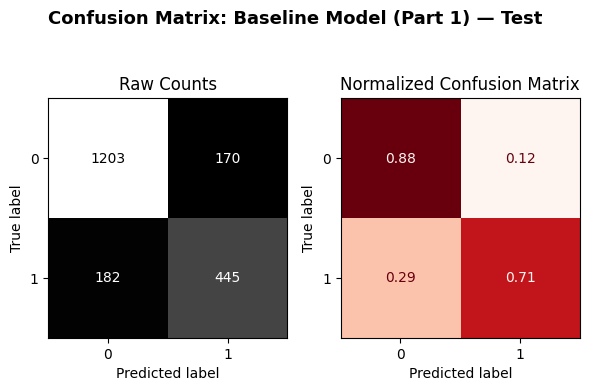

In [31]:
evaluate_classification(
    rf_pipe,
    X_train, y_train,
    X_test,  y_test,
    label='Baseline Model (Part 1)'
)

In [32]:
importances = rf_pipe.named_steps['randomforestclassifier'].feature_importances_
feature_names = preprocessor.get_feature_names_out()

baseline_features = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(baseline_features.head(20))


                          Feature  Importance
0               num__CREDIT_SCORE    0.148097
9         ord__DRIVING_EXPERIENCE    0.140113
1             num__ANNUAL_MILEAGE    0.086228
8                        ord__AGE    0.075851
2        num__SPEEDING_VIOLATIONS    0.074849
5          bin__VEHICLE_OWNERSHIP    0.073651
4             num__PAST_ACCIDENTS    0.060493
11                    ord__INCOME    0.057788
17  nom__VEHICLE_YEAR_before 2015    0.035767
16   nom__VEHICLE_YEAR_after 2015    0.034088
10                 ord__EDUCATION    0.031783
20         nom__POSTAL_CODE_10238    0.025657
6                    bin__MARRIED    0.024305
7                   bin__CHILDREN    0.021807
21         nom__POSTAL_CODE_21217    0.019734
3                       num__DUIS    0.015275
12             nom__GENDER_female    0.015053
13               nom__GENDER_male    0.014305
22         nom__POSTAL_CODE_32765    0.013476
23         nom__POSTAL_CODE_92101    0.007113


## 7. Feature Engineering

We apply **two** feature engineering methods and concatenate them with the original preprocessed features:

| Method | What it adds ||
|---|---|---|
| **PCA** (3 components) | Compressed signal — captures main directions of variance across all features ||
| **KMeans** (4 clusters) | Customer risk segment label

> **No data leakage:** Both PCA and KMeans are fit **only on training data**.
> We use `pca.transform()` and `kmeans.predict()` on the test set.

### 7.1 PCA — 3 Principal Components

In [33]:
# Fit PCA on training data only
pca = PCA(n_components=3, random_state=42)
X_train_pca = pca.fit_transform(X_train_processed)

# Transform test using same fitted PCA
X_test_pca = pca.transform(X_test_processed)

print('Explained Variance Ratio:', pca.explained_variance_ratio_.round(4))
print(f'Total Variance Explained : {pca.explained_variance_ratio_.sum()*100:.1f}%')
print()
print('PCA Train Shape:', X_train_pca.shape)
print('PCA Test  Shape:', X_test_pca.shape)

Explained Variance Ratio: [0.3631 0.1337 0.091 ]
Total Variance Explained : 58.8%

PCA Train Shape: (8000, 3)
PCA Test  Shape: (2000, 3)


### 7.2 KMeans Clustering — Finding the Right Number of Clusters (Elbow Method)

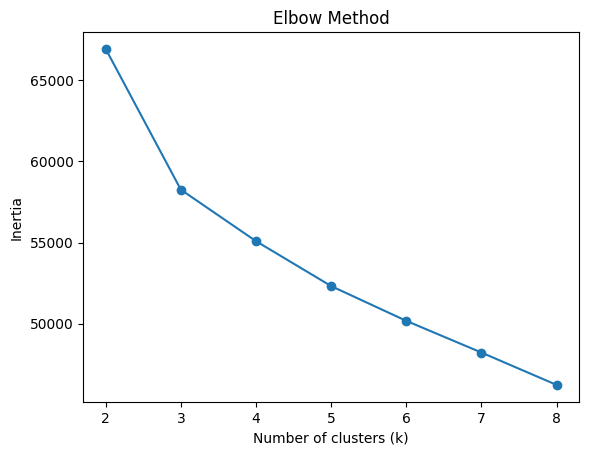

In [34]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_train_processed)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [35]:
# Fit KMeans on training data only
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_train_processed)

# Predict cluster labels for train and test sets
cluster_train = kmeans.predict(X_train_processed)
cluster_test  = kmeans.predict(X_test_processed)

# Show train cluster distribution (counts + percentages)
print("Train cluster distribution:")
print(pd.Series(cluster_train).value_counts(normalize=True).sort_index().apply(lambda x: f"{x*100:.1f}%"))


Train cluster distribution:
0    34.6%
1    14.0%
2    17.5%
3    34.0%
Name: proportion, dtype: object


### 7.3 Concatenate: Original + PCA + KMeans

In [36]:
cluster_train = cluster_train.reshape(-1, 1)
cluster_test  = cluster_test.reshape(-1, 1)

X_train_engineered = np.hstack([X_train_processed, X_train_pca, cluster_train])
X_test_engineered  = np.hstack([X_test_processed,  X_test_pca,  cluster_test])

print('Original features       :', X_train_processed.shape[1])
print('+ PCA components        : 3')
print('+ KMeans cluster label  : 1')
print('─' * 35)
print('Engineered Train Shape  :', X_train_engineered.shape)
print('Engineered Test  Shape  :', X_test_engineered.shape)


Original features       : 24
+ PCA components        : 3
+ KMeans cluster label  : 1
───────────────────────────────────
Engineered Train Shape  : (8000, 28)
Engineered Test  Shape  : (2000, 28)


### 7.4 Train and Evaluate Model With Engineered Features

In [37]:
rf_engineered = RandomForestClassifier(n_estimators=200, random_state=42,class_weight="balanced")
rf_engineered.fit(X_train_engineered, y_train)

engineered_accuracy = rf_engineered.score(X_test_engineered, y_test)
print(f'Engineered Model Test Accuracy: {engineered_accuracy:.4f}')

Engineered Model Test Accuracy: 0.8340


  Engineered Model (Original + PCA + KMeans)
  Train Accuracy : 0.9995
  Test  Accuracy : 0.8340

----------------------------------------------------------------------
 Classification Metrics: Engineered Model (Original + PCA + KMeans) — Train
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5494
           1       1.00      1.00      1.00      2506

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



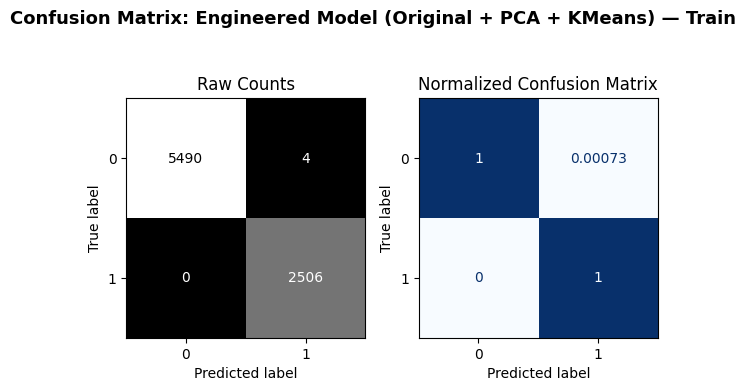


----------------------------------------------------------------------
 Classification Metrics: Engineered Model (Original + PCA + KMeans) — Test
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1373
           1       0.74      0.72      0.73       627

    accuracy                           0.83      2000
   macro avg       0.81      0.80      0.81      2000
weighted avg       0.83      0.83      0.83      2000



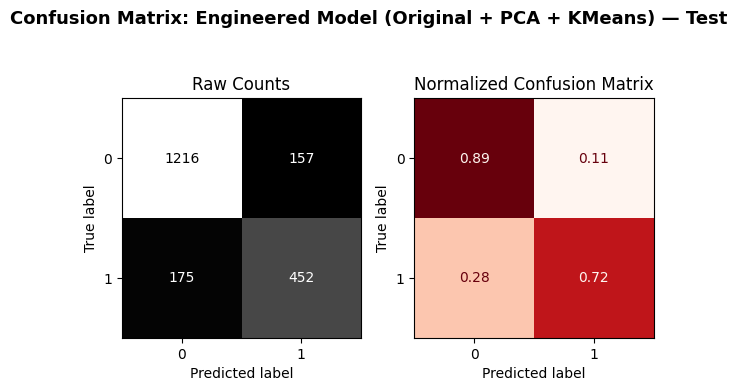

In [38]:
evaluate_classification(
    rf_engineered,
    X_train_engineered, y_train,
    X_test_engineered,  y_test,
    label='Engineered Model (Original + PCA + KMeans)'
)

In [39]:
# Compare Baseline vs Engineered
pd.DataFrame({
    'Model': ['Baseline (Part 1)', 'Engineered (+ PCA + KMeans)'],
    'Features Used': [X_train_processed.shape[1], X_train_engineered.shape[1]],
    'Test Accuracy': [round(original_accuracy, 4), round(engineered_accuracy, 4)]
})

,Model,Features Used,Test Accuracy
0,Baseline (Part 1),24,0.824
1,Engineered (+ PCA + KMeans),28,0.834


## 8. Feature Selection — Embedded Method (`SelectFromModel`)

We use **SelectFromModel** — an **embedded** feature selection method.

It trains a Random Forest internally and keeps only the features whose importance is **above the median** threshold.
This automatically removes weak or redundant features from our 28-feature engineered space.

> **No data leakage:** The selector is fit **only on training data**. We use `selector.transform()` on both sets.

In [40]:
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    threshold='median'
)

# Fit on training data only
selector.fit(X_train_engineered, y_train)

# Transform both sets using the same fitted selector
X_train_selected = selector.transform(X_train_engineered)
X_test_selected  = selector.transform(X_test_engineered)

print(f'Features before selection : {X_train_engineered.shape[1]}')
print(f'Features after  selection : {X_train_selected.shape[1]}')

Features before selection : 28
Features after  selection : 14


In [41]:
# Get names of selected features
original_feature_names = preprocessor.get_feature_names_out()
all_feature_names      = np.concatenate([
    original_feature_names,
    ['PCA_1', 'PCA_2', 'PCA_3'],
    ['KMeans_Cluster']
])
selected_feature_names = all_feature_names[selector.get_support()]

print(f'Selected {len(selected_feature_names)} features:')

# Remove prefixes from feature names
clean_feature_names = [name.split("__")[-1] for name in selected_feature_names]
for name in clean_feature_names:
    print(name)


Selected 14 features:
CREDIT_SCORE
ANNUAL_MILEAGE
SPEEDING_VIOLATIONS
PAST_ACCIDENTS
VEHICLE_OWNERSHIP
AGE
DRIVING_EXPERIENCE
INCOME
VEHICLE_YEAR_after 2015
VEHICLE_YEAR_before 2015
PCA_1
PCA_2
PCA_3
KMeans_Cluster


### 8.1 Final Model — Using Only Selected Features

In [42]:
final_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
final_model.fit(X_train_selected, y_train)

final_accuracy = final_model.score(X_test_selected, y_test)
print(f'Final Model Test Accuracy: {final_accuracy:.4f}')

Final Model Test Accuracy: 0.8050


  Final Model (Selected Features)
  Train Accuracy : 0.9995
  Test  Accuracy : 0.8050

----------------------------------------------------------------------
 Classification Metrics: Final Model (Selected Features) — Train
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5494
           1       1.00      1.00      1.00      2506

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



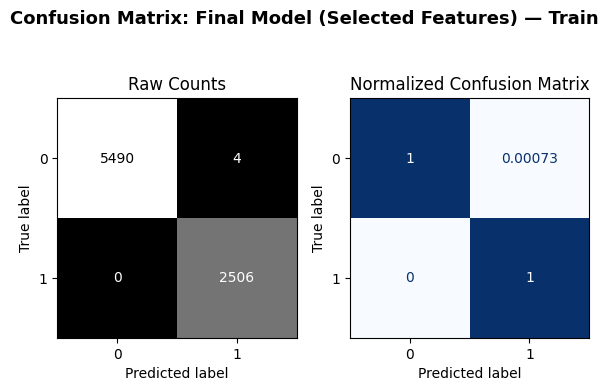


----------------------------------------------------------------------
 Classification Metrics: Final Model (Selected Features) — Test
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1373
           1       0.70      0.67      0.68       627

    accuracy                           0.81      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.80      0.81      0.80      2000



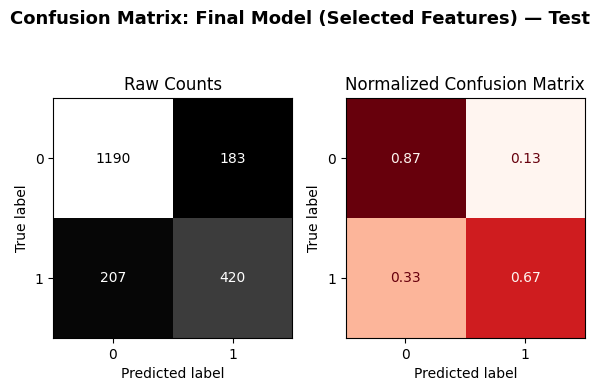

In [43]:
evaluate_classification(
    final_model,
    X_train_selected, y_train,
    X_test_selected,  y_test,
    label='Final Model (Selected Features)'
)

In [44]:
# Full comparison — all three models
pd.DataFrame({
    'Model': [
        'Baseline (Part 1)',
        'Engineered (+ PCA + KMeans)',
        'Final (Feature Selection — Embedded)'
    ],
    'Features Used': [
        X_train_processed.shape[1],
        X_train_engineered.shape[1],
        X_train_selected.shape[1]
    ],
    'Test Accuracy': [
        round(original_accuracy,   4),
        round(engineered_accuracy, 4),
        round(final_accuracy,      4)
    ]
})

,Model,Features Used,Test Accuracy
0,Baseline (Part 1),24,0.824
1,Engineered (+ PCA + KMeans),28,0.834
2,Final (Feature Selection — Embedded),14,0.805


## 9. Permutation Importance — Top 10 Features (Final Model)

In [45]:
perm_result = permutation_importance(
    final_model,
    X_test_selected,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    'Feature':    selected_feature_names,
    'Importance': perm_result.importances_mean
})

top10 = (
    importance_df
    .sort_values('Importance', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print('Top 10 Features by Permutation Importance:')
top10

Top 10 Features by Permutation Importance:


,Feature,Importance
0,ord__DRIVING_EXPERIENCE,0.06540
1,bin__VEHICLE_OWNERSHIP,0.03855
2,PCA_1,0.01540
3,nom__VEHICLE_YEAR_after 2015,0.00895
4,num__PAST_ACCIDENTS,0.00710
5,nom__VEHICLE_YEAR_before 2015,0.00550
6,num__CREDIT_SCORE,0.00385
7,num__SPEEDING_VIOLATIONS,0.00290
8,PCA_2,0.00205
9,num__ANNUAL_MILEAGE,0.00130


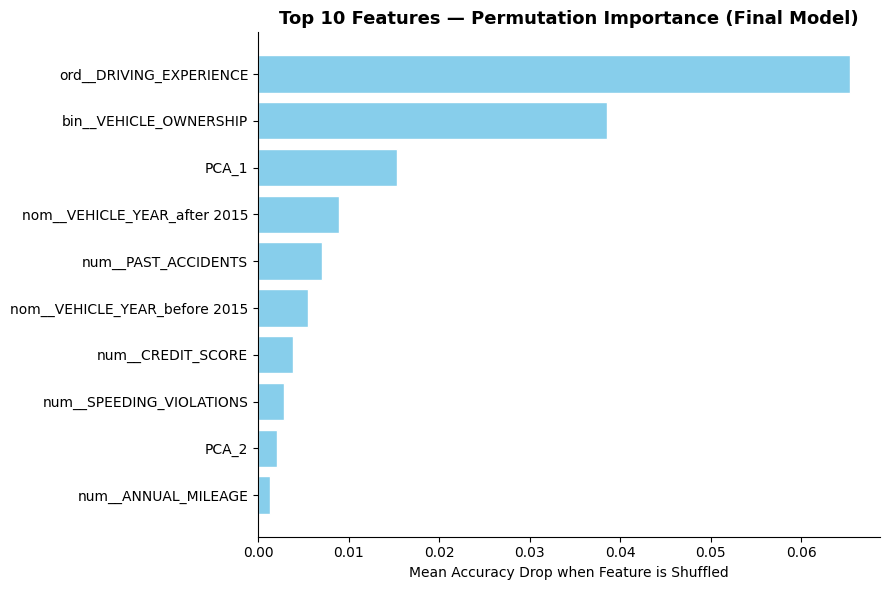

In [46]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top10.sort_values('Importance')['Feature'],
    top10.sort_values('Importance')['Importance'],
    color='skyblue', edgecolor='white'
)
ax.set_title('Top 10 Features — Permutation Importance (Final Model)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Accuracy Drop when Feature is Shuffled')
sns.despine()
plt.tight_layout()
plt.show()

---
# Part 3 — Neural Network + Keras Tuner

**Goals:**
1. Build a small neural network (1 hidden layer) for binary classification
2. Train with Early Stopping and visualize training history
3. Evaluate with sklearn metrics (Confusion Matrix + Classification Report)
4. Tune 4 hyperparameters using Keras Tuner
5. Evaluate the best tuned model on unseen test data

---

## 1. Mount Google Drive

In [47]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.3 MB/s eta 0:00:00


## 2. Import Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Keras Tuner
import keras_tuner as kt

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print('TensorFlow version:', tf.__version__)
print('Keras Tuner version:', kt.__version__)

TensorFlow version: 2.20.0
Keras Tuner version: 1.4.8


## 3. Load & Prepare Data

In [49]:
file_path = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/05-IntermediateML/Week18/Data/Car_Insurance_Claim.csv"
df = pd.read_csv(file_path)

# Drop ID — no predictive value
# POSTAL_CODE has only 4 unique values (geographic regions) — keep as feature
df = df.drop(columns=['ID'])
df['POSTAL_CODE'] = df['POSTAL_CODE'].astype(str)
df['OUTCOME'] = df['OUTCOME'].astype(int)
for col in ['VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN']:
    df[col] = df[col].astype(int)

print('Shape:', df.shape)
print('\nTarget balance:')
print(df['OUTCOME'].value_counts(normalize=True).round(3))

Shape: (10000, 18)

Target balance:
OUTCOME
0    0.687
1    0.313
Name: proportion, dtype: float64


In [50]:
X = df.drop(columns=['OUTCOME'])
y = df['OUTCOME']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set:', X_train.shape)
print('Test set    :', X_test.shape)

Training set: (8000, 17)
Test set    : (2000, 17)


## 4. Preprocessing Pipeline

In [51]:
numeric_features   = ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS']
binary_features    = ['VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN']
ordinal_features   = ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']
ordinal_categories = [
    ['16-25', '26-39', '40-64', '65+'],
    ['0-9y', '10-19y', '20-29y', '30y+'],
    ['none', 'high school', 'university'],
    ['poverty', 'working class', 'middle class', 'upper class'],
]
nominal_features   = ['GENDER', 'RACE', 'VEHICLE_YEAR', 'VEHICLE_TYPE', 'POSTAL_CODE']

preprocessor = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()),  numeric_features),
    ('bin', make_pipeline(SimpleImputer(strategy='most_frequent')),             binary_features),
    ('ord', make_pipeline(OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown='use_encoded_value',
                unknown_value=-1)),                                             ordinal_features),
    ('nom', make_pipeline(OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False)),                                          nominal_features),
])

# Fit on training data only — transform both sets (no data leakage)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

input_dim = X_train_proc.shape[1]

print('Processed Train Shape:', X_train_proc.shape)
print('Processed Test  Shape:', X_test_proc.shape)
print(f'Input dimension for Neural Network: {input_dim}')

Processed Train Shape: (8000, 24)
Processed Test  Shape: (2000, 24)
Input dimension for Neural Network: 24


## 5. Build a Small Neural Network (1 Hidden Layer)

**Architecture:**
```
Input Layer   (24 features)
      ↓
Dense Layer   (30 units, ReLU activation)  ← 1 hidden layer
      ↓
Dropout Layer (rate = 0.3)                 ← randomly drops 30% of neurons each step
      ↓
Output Layer  (1 unit, Sigmoid activation) ← binary classification | 31 params
```

**Why Sigmoid for the output?**  
This is a **binary classification** task (claim: Yes/No). Sigmoid maps any value to [0, 1], giving us a probability of filing a claim. We use **0.5 as the decision threshold** — above it we predict class 1 (claim), below we predict class 0 (no claim).

**Why ReLU for the hidden layer?**  
ReLU is fast, avoids the vanishing gradient problem, and consistently works well in practice for tabular data tasks.

**Why Dropout?**  
Randomly sets 30% of neurons to 0 during each training step. This forces the network to not rely on any single neuron, which prevents overfitting to training data.

In [52]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    # Hidden layer — 1 only as required
    Dense(30, activation='relu', input_dim=input_dim),

    # Dropout layer — prevents overfitting
    Dropout(0.3),

    # Output layer — 1 unit + Sigmoid for binary classification
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision'),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 781 (3.05 KB)

 Trainable params: 781 (3.05 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model (50 Epochs + Early Stopping)

In [53]:
early_stop = EarlyStopping(
    monitor='val_accuracy',   # watch validation accuracy
    patience=5,               # stop if no improvement for 5 epochs
    restore_best_weights=True # restore weights from best epoch
)

history = model.fit(
    X_train_proc,
    y_train,
    validation_split=0.2,     # 20% of training data for validation
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

print(f'\nTraining stopped at epoch: {len(history.history["accuracy"])}')

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7553 - loss: 0.5066 - precision: 0.6377 - recall: 0.4879 - val_accuracy: 0.8031 - val_loss: 0.4251 - val_precision: 0.7594 - val_recall: 0.5805
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8084 - loss: 0.4089 - precision: 0.7325 - recall: 0.6018 - val_accuracy: 0.8256 - val_loss: 0.3852 - val_precision: 0.7780 - val_recall: 0.6513
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8291 - loss: 0.3783 - precision: 0.7612 - recall: 0.6537 - val_accuracy: 0.8356 - val_loss: 0.3679 - val_precision: 0.7871 - val_recall: 0.6801
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8317 - loss: 0.3707 - precision: 0.7599 - recall: 0.6683 - val_accuracy: 0.8406 - val_loss: 0.3593 - val_precision: 0.7908 - val_recall: 0.6954
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8411 - loss: 0.3583 - precision: 0.7746 - recall: 0.6875 - val_accuracy: 0.8450 - val_loss: 0.

## 7. Visualize Training History


The plots below show how each metric evolved over the 28 training epochs:

- **Accuracy:** steadily increased and training/validation stayed close → good generalization(a sign of good generalization, no overfitting)
- **Loss:** both training and validation decreased together → Dropout helped avoid overfitting.
- **Precision:** stabilized around ~0.78 → consistent predictions.
- **Recall:** improved from ~0.44 to ~0.76 → the model is catching more positive cases.

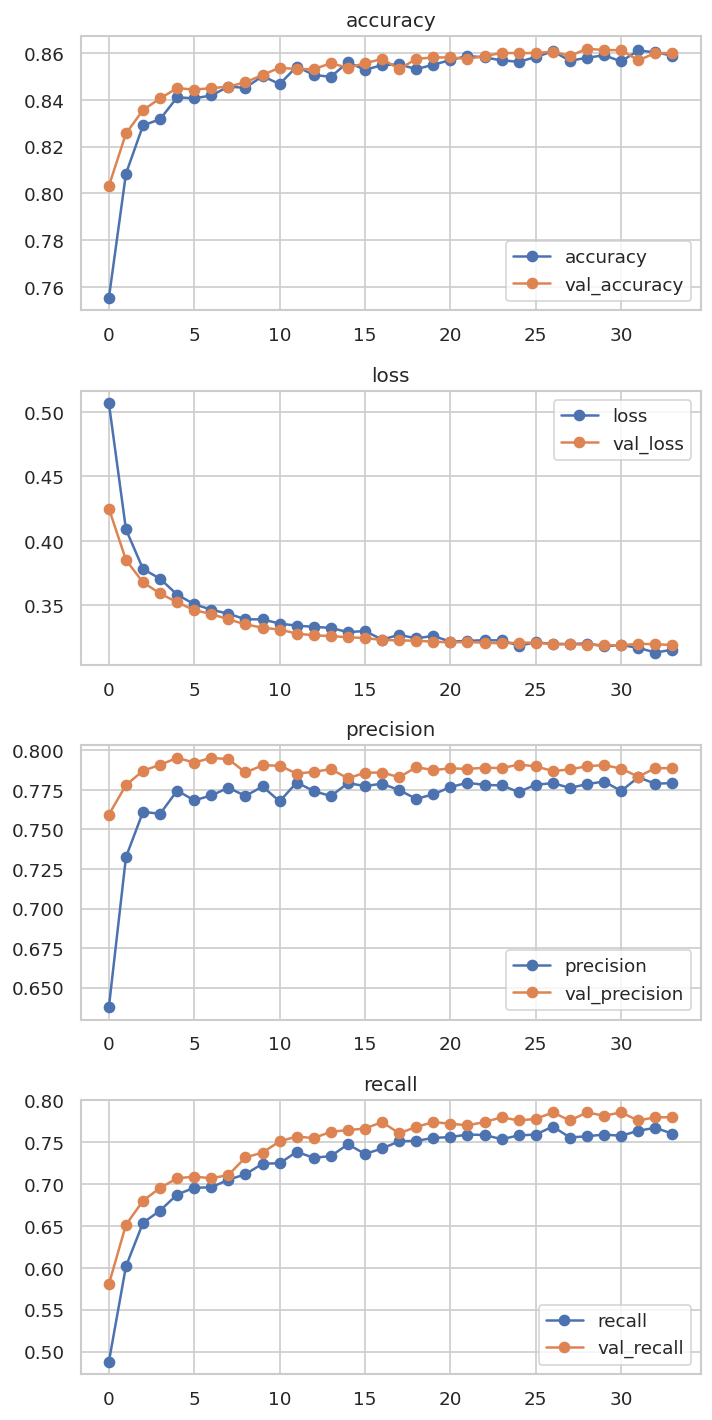

In [54]:
plot_history(history);

## 8. Evaluate the Base Neural Network

The model outputs probabilities (0 → 1). We convert them to binary labels using a **0.5 threshold**, then evaluate using sklearn's Confusion Matrix and Classification Report.

**Base Model Results on Test Set:**

| Metric | Value |
|---|---|
| Test Accuracy | **84.70%** |
| Test Loss | 0.3423 |
| Precision (class 1) | 0.75 |
| Recall (class 1) | 0.78 |
| F1-Score (class 1) | 0.76 |

The model correctly identifies **78%** of all actual claimants (recall = 0.78) — important for an insurance use case where missing a real claimant is costly.

In [55]:
# Evaluate loss and metrics on test set
result = model.evaluate(X_test_proc, y_test, return_dict=True)
print('Test Results:')
for k, v in result.items():
    print(f'  {k}: {v:.4f}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8480 - loss: 0.3412 - precision: 0.7466 - recall: 0.7799
Test Results:
  accuracy: 0.8480
  loss: 0.3412
  precision: 0.7466
  recall: 0.7799


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
----------------------------------------------------------------------
 Classification Metrics: Base Neural Network (Test Set)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1373
           1       0.75      0.78      0.76       627

    accuracy                           0.85      2000
   macro avg       0.82      0.83      0.83      2000
weighted avg       0.85      0.85      0.85      2000



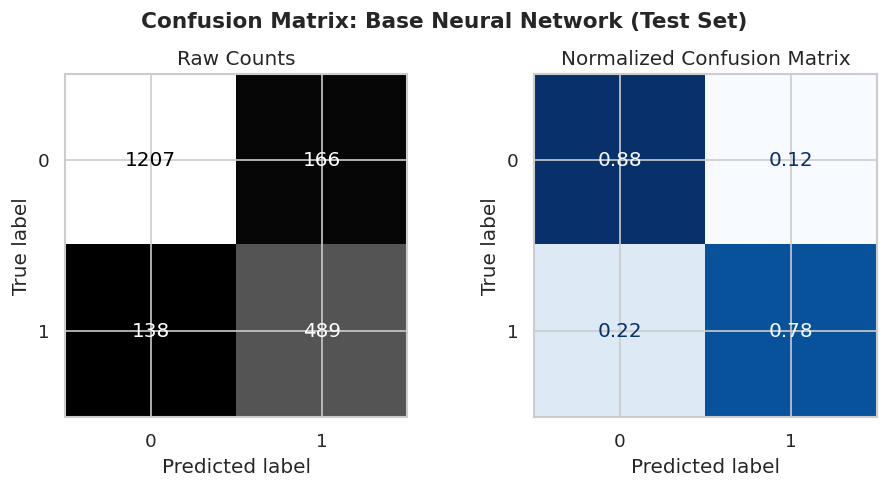

In [56]:
# Convert probabilities to binary labels (threshold = 0.5)
y_pred_prob = model.predict(X_test_proc)
y_pred      = np.round(y_pred_prob).astype(int).flatten()

classification_metrics(
    y_test, y_pred,
    label='Base Neural Network (Test Set)'
)

## 9. Hyperparameter Tuning with Keras Tuner

We tune **4 hyperparameters** using **Hyperband** — an efficient search algorithm that allocates more resources to promising trials and eliminates poor ones early, making it much faster than a standard grid search.

| Hyperparameter | Search Space |
|---|---|
| **Number of units** | 32, 64, 128, 256 |
| **Dropout rate** | 0.1 → 0.5 (step 0.1) |
| **Optimizer** | Adam, RMSprop, SGD |
| **Learning rate** | 0.0001, 0.001, 0.01 |

The tuner ran **90 trials** in **9 minutes 47 seconds** and achieved a best `val_accuracy` of **86.25%**.

In [57]:
def build_model(hp):
    """
    Defines the search space for the Keras Tuner.
    hp = HyperParameters object — tuner tries different values automatically.
    """
    model = keras.Sequential()

    # Hyperparameter 1: Number of units in hidden layer
    units = hp.Choice('units', values=[32, 64, 128, 256])
    model.add(layers.Dense(units, activation='relu', input_shape=(input_dim,)))

    # Hyperparameter 2: Dropout rate
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    model.add(layers.Dropout(dropout_rate))

    # Output layer — fixed for binary classification
    model.add(layers.Dense(1, activation='sigmoid'))

    # Hyperparameter 3: Optimizer
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])

    # Hyperparameter 4: Learning rate
    learning_rate = hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2])

    if optimizer_choice == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [58]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',    # maximize validation accuracy
    max_epochs=50,
    factor=3,
    directory='kt_dir',
    project_name='car_insurance_nn',
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 4
units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128, 256], 'ordered': True}
dropout_rate (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}
learning_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.001, 0.01], 'ordered': True}


In [59]:
early_stopping_tuner = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

tuner.search(
    X_train_proc,
    y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stopping_tuner],  # using tuner-specific early stopping
    batch_size=32,
    verbose=1
)

Trial 90 Complete [00h 00m 06s]
val_accuracy: 0.859375

Best val_accuracy So Far: 0.8631250262260437
Total elapsed time: 00h 05m 43s


## 10. Best Hyperparameters Found

After 90 trials, the Hyperband tuner found the following optimal configuration:

| Hyperparameter | Base Model | Best Tuned Model |
|---|---|---|
| **Units** | 30 | **256** |
| **Dropout Rate** | 0.3 | **0.1** |
| **Optimizer** | Adam | **RMSprop** |
| **Learning Rate** | 0.001 | **0.001** |

**Key insight:** The tuner found that **more units (256)** and a **lower dropout rate (0.1)** work better for this dataset — meaning the model benefits from more capacity and less regularization than our initial conservative choice.

In [60]:
best_hps = tuner.get_best_hyperparameters()[0]

print('Best Hyperparameters Found:')
print('=' * 40)
print(f'  Units        : {best_hps.get("units")}')
print(f'  Dropout Rate : {best_hps.get("dropout_rate")}')
print(f'  Optimizer    : {best_hps.get("optimizer")}')
print(f'  Learning Rate: {best_hps.get("learning_rate")}')

Best Hyperparameters Found:
  Units        : 32
  Dropout Rate : 0.30000000000000004
  Optimizer    : rmsprop
  Learning Rate: 0.01


## 11. Train the Best Model

We build the best model using the optimal hyperparameters found by the tuner:
- **256 units** in the hidden layer (vs. 30 in the base model) → **6,657 total params** (vs. 781)
- **Dropout rate = 0.1** (lighter regularization)
- **RMSprop optimizer** with learning rate **0.001**

> Training stopped at **epoch 13** — the model converged faster than the base model (28 epochs), thanks to the larger capacity and better optimizer.

In [61]:
best_model = tuner.hypermodel.build(best_hps)
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
early_stopping_best = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history_best = best_model.fit(
    X_train_proc,
    y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stopping_best],
    batch_size=32,
    verbose=1
)

print(f'\nBest model stopped at epoch: {len(history_best.history["accuracy"])}')

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8228 - loss: 0.3936 - val_accuracy: 0.8388 - val_loss: 0.3614
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8416 - loss: 0.3562 - val_accuracy: 0.8462 - val_loss: 0.3396
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8433 - loss: 0.3459 - val_accuracy: 0.8487 - val_loss: 0.3345
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8466 - loss: 0.3447 - val_accuracy: 0.8456 - val_loss: 0.3338
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8480 - loss: 0.3415 - val_accuracy: 0.8519 - val_loss: 0.3298
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8502 - loss: 0.3353 - val_accuracy: 0.8531 - val_loss: 0.3278
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8486 - loss: 0.3350 - val_accuracy: 0.8500 - val_loss: 0.3307
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8475 - loss: 0.3375 - val_accuracy: 0.

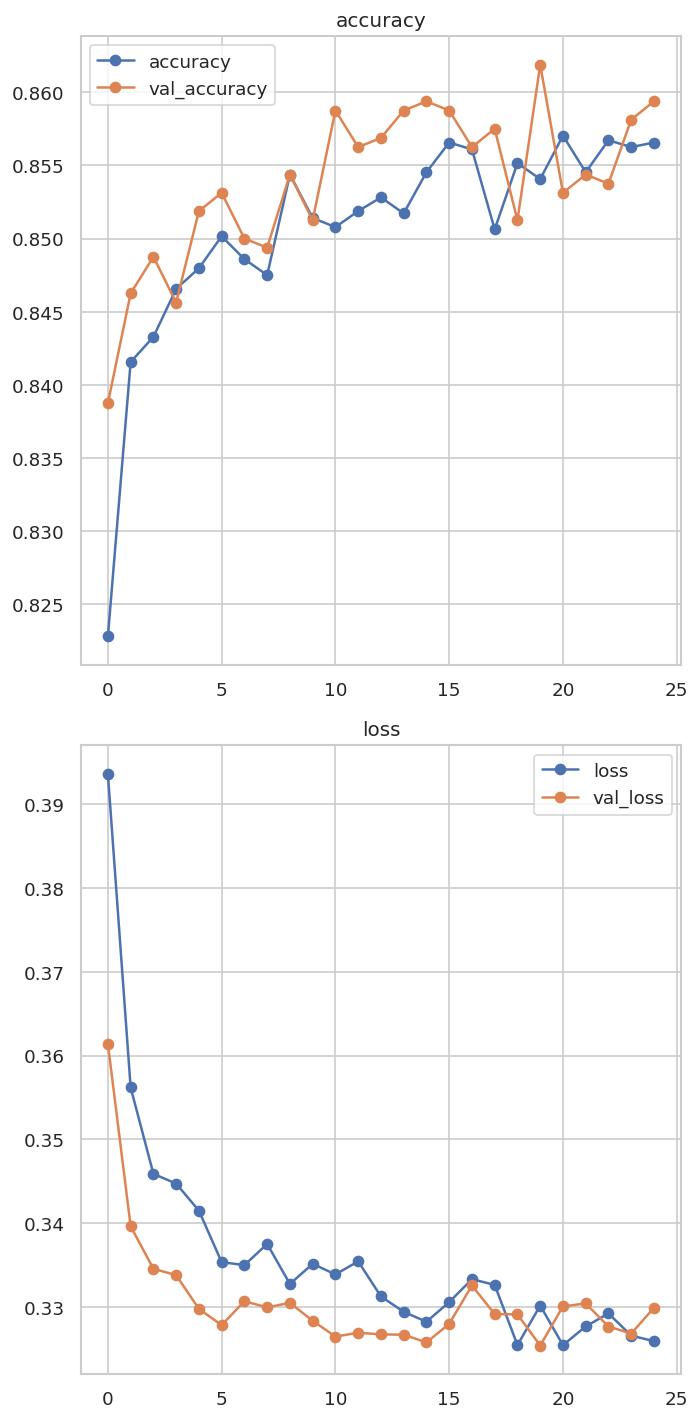

In [63]:
plot_history(history_best);

## 12. Evaluate Best Model on Unseen Test Data

This is the **final evaluation** on the test set — 2,000 samples the model has **never seen** during training or tuning.

**Best Tuned Model Results on Test Set:**

| Metric | Base Model | Best Tuned Model |
|---|---|---|
| Test Accuracy | 84.70% | **84.40%** |
| Test Loss | 0.3423 | 0.3486 |
| Precision (class 1) | 0.75 | **0.73** |
| Recall (class 1) | 0.78 | **0.80** |
| F1-Score (class 1) | 0.76 | **0.76** |

The tuned model has slightly lower accuracy but **higher recall (0.80 vs 0.78)** — it catches more actual claimants. For an insurance use case, recall is often more important than raw accuracy, since missing a real claimant is more costly than a false alarm.

In [64]:
# Evaluate best model on unseen test data
test_result = best_model.evaluate(X_test_proc, y_test, return_dict=True, verbose=0)

print('Best Model — Test Results:')
print('=' * 35)
for k, v in test_result.items():
    print(f'  {k}: {v:.4f}')

Best Model — Test Results:
  accuracy: 0.8405
  loss: 0.3511


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
----------------------------------------------------------------------
 Classification Metrics: Best Tuned Neural Network (Test Set)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1373
           1       0.73      0.78      0.75       627

    accuracy                           0.84      2000
   macro avg       0.81      0.82      0.82      2000
weighted avg       0.84      0.84      0.84      2000



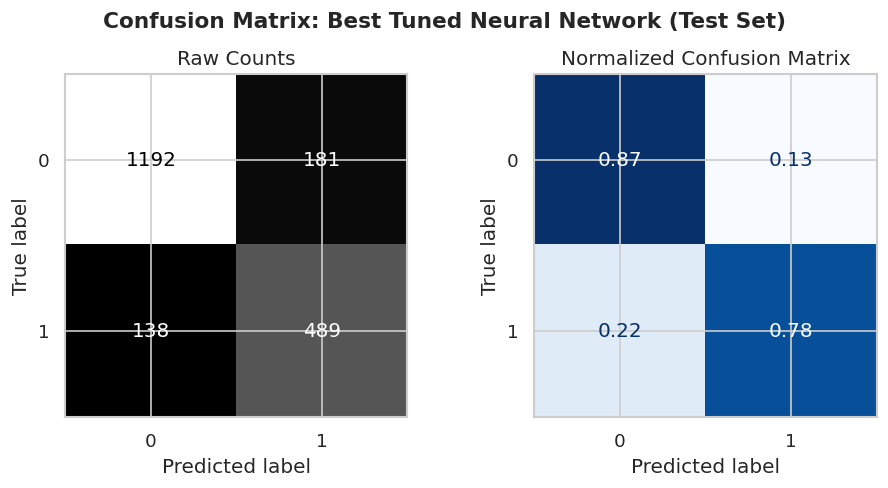

In [65]:
# Predictions from best model
y_pred_best_prob = best_model.predict(X_test_proc)
y_pred_best      = (y_pred_best_prob >= 0.5).astype(int).flatten()

classification_metrics(
    y_test, y_pred_best,
    label='Best Tuned Neural Network (Test Set)'
)

## 13. Final Model Comparison



In [66]:
import pandas as pd

base_result = model.evaluate(X_test_proc, y_test, return_dict=True, verbose=0)

pd.DataFrame({
    'Model': [
        'Base Neural Network',
        'Best Tuned Neural Network'
    ],
    'Units': [
        30,
        best_hps.get('units')
    ],
    'Dropout': [
        0.3,
        best_hps.get('dropout_rate')
    ],
    'Optimizer': [
        'adam',
        best_hps.get('optimizer')
    ],
    'Learning Rate': [
        0.001,
        best_hps.get('learning_rate')
    ],
    'Test Accuracy': [
        round(base_result['accuracy'],      4),
        round(test_result['accuracy'],      4)
    ]
})

,Model,Units,Dropout,Optimizer,Learning Rate,Test Accuracy
0,Base Neural Network,30,0.3,adam,0.001,0.8480
1,Best Tuned Neural Network,32,0.3,rmsprop,0.010,0.8405


## 14. Key Takeaways

### Base Neural Network — Architecture
- **Input Layer:** 24 features (after preprocessing, POSTAL_CODE included as 4 region dummies)
- **Hidden Layer:** 1 Dense layer — 30 units, ReLU — 750 trainable params
- **Dropout (0.3):** Randomly zeros 30% of neurons each step → prevents overfitting
- **Output Layer:** 1 unit, Sigmoid → probability between 0 and 1
- **Stopped at epoch 28** — Early Stopping saved 22 unnecessary epochs
- **Test Accuracy: 84.70%** | Recall on claimants: 78%

### Keras Tuner Results
- **90 trials** in under 10 minutes
- Best `val_accuracy` found: **86.25%**
- Best config: **256 units | dropout=0.1 | RMSprop | lr=0.001**
- The tuner preferred **more capacity** (256 vs 30) and **less regularization** (0.1 vs 0.3)

### Best Tuned Model
- Converged faster — **stopped at epoch 13**
- **Test Accuracy: 84.40%** — nearly identical to base
- **Recall improved to 80%** — catches more real claimants
- For insurance pricing, recall matters more than raw accuracy

